In [346]:
import uhd                                                                                                                                                       
import numpy as np                                                                                                                                               
                                                                                                                                                                    
# --- 1. CONFIGURACIÓN ---                                                                                                                                       
sample_rate = 3.84e6  # 3.84 MHz para celda LTE de 3MHz                                                                             
center_freq = 1732.5e6    # Cambiar por la frecuencia de la celda / Uplink a analizar                                                                               
ganancia = 40          # Ganancia de la B200                                                                                                                     
                                                                                                                                                                    
# Tiempo de captura: 100 ms (10 tramas completas)                                                                                                                
tiempo_captura = 0.1                                                                                                                                             
num_samps = int(sample_rate * tiempo_captura)                                                                                                                    
                                                                                                                                                                    
print(f"Preparando USRP para capturar {num_samps} muestras ({tiempo_captura*1000} ms)...")                                                                       
                                                                                                                                                                    
# --- 2. INICIALIZAR USRP ---                                                                                                                                    
# Usamos los mismos parámetros que el ettus_usrpb200_handler.py                                                                                                  
usrp = uhd.usrp.MultiUSRP("type=b200")                                                                                                                           
usrp.set_master_clock_rate(61.44e6)  # Reloj base ideal para tasas de LTE                                                                                        
usrp.set_rx_rate(sample_rate, 0)                                                                                                                                 
usrp.set_rx_bandwidth(sample_rate, 0)                                                                                                                            
                                                                                                                                                                    
tune_req = uhd.types.TuneRequest(center_freq)                                                                                                                    
usrp.set_rx_freq(tune_req, 0)                                                                                                                                    
usrp.set_rx_gain(ganancia, 0)                                                                                                                                    
                                                                                                                                                                    
# --- 3. CONFIGURAR STREAMER ---                                                                                                                                 
# fc32 = Host format (Float Complex 32 bits = np.complex64)                                                                                                      
# sc16 = Wire format (optimiza el ancho de banda USB)                                                                                                            
st_args = uhd.usrp.StreamArgs("fc32", "sc16")                                                                                                                    
st_args.channels = [0]                                                                                                                                           
streamer = usrp.get_rx_stream(st_args)                                                                                                                           
                                                                                                                                                                    
# --- 4. CAPTURAR ---                                                                                                                                            
stream_cmd = uhd.types.StreamCMD(uhd.types.StreamMode.start_cont)                                                                                                
stream_cmd.stream_now = True                                                                                                                                     
streamer.issue_stream_cmd(stream_cmd)                                                                                                                            
                                                                                                                                                                    
# Nuestro buffer gigante para la captura offline                                                                                                                 
recv_buffer = np.zeros(num_samps, dtype=np.complex64)                                                                                                            
metadata = uhd.types.RXMetadata()                                                                                                                                
                                                                                                                                                                    
samps_received = 0                                                                                                                                               
# Buffer temporal del tamaño máximo por transacción que soporta el streamer                                                                                      
max_samps_per_packet = streamer.get_max_num_samps()                                                                                                              
buffer_chunk = np.zeros(max_samps_per_packet, dtype=np.complex64)                                                                                                
                                                                                                                                                                    
print("Iniciando captura...")                                                                                                                                    
while samps_received < num_samps:                                                                                                                                
    samps = streamer.recv(buffer_chunk, metadata)                                                                                                                
                                                                                                                                                                    
    if metadata.error_code != uhd.types.RXMetadataErrorCode.none:                                                                                                
        print(f"Alerta de stream: {metadata.error_code}")                                                                                                        
                                                                                                                                                                    
    if samps > 0:                                                                                                                                                
        # Calcular cuántas muestras nos faltan para no pasarnos del tamaño del buffer final                                                                      
        samps_to_copy = min(samps, num_samps - samps_received)
        recv_buffer[samps_received : samps_received + samps_to_copy] = buffer_chunk[:samps_to_copy]
        samps_received += samps_to_copy

# Detener stream
stop_cmd = uhd.types.StreamCMD(uhd.types.StreamMode.stop_cont)
streamer.issue_stream_cmd(stop_cmd)

print(f"¡Captura finalizada! {samps_received} muestras guardadas en la variable 'recv_buffer'.")

# Opcional: Si querés guardar la captura a un archivo para abrirla sin conectar la SDR:
# np.save('muestras_uplink_100ms.npy', recv_buffer)

Preparando USRP para capturar 384000 muestras (100.0 ms)...
Iniciando captura...
¡Captura finalizada! 384000 muestras guardadas en la variable 'recv_buffer'.


[INFO] [B200] Asking for clock rate 61.440000 MHz... 
[INFO] [B200] OK


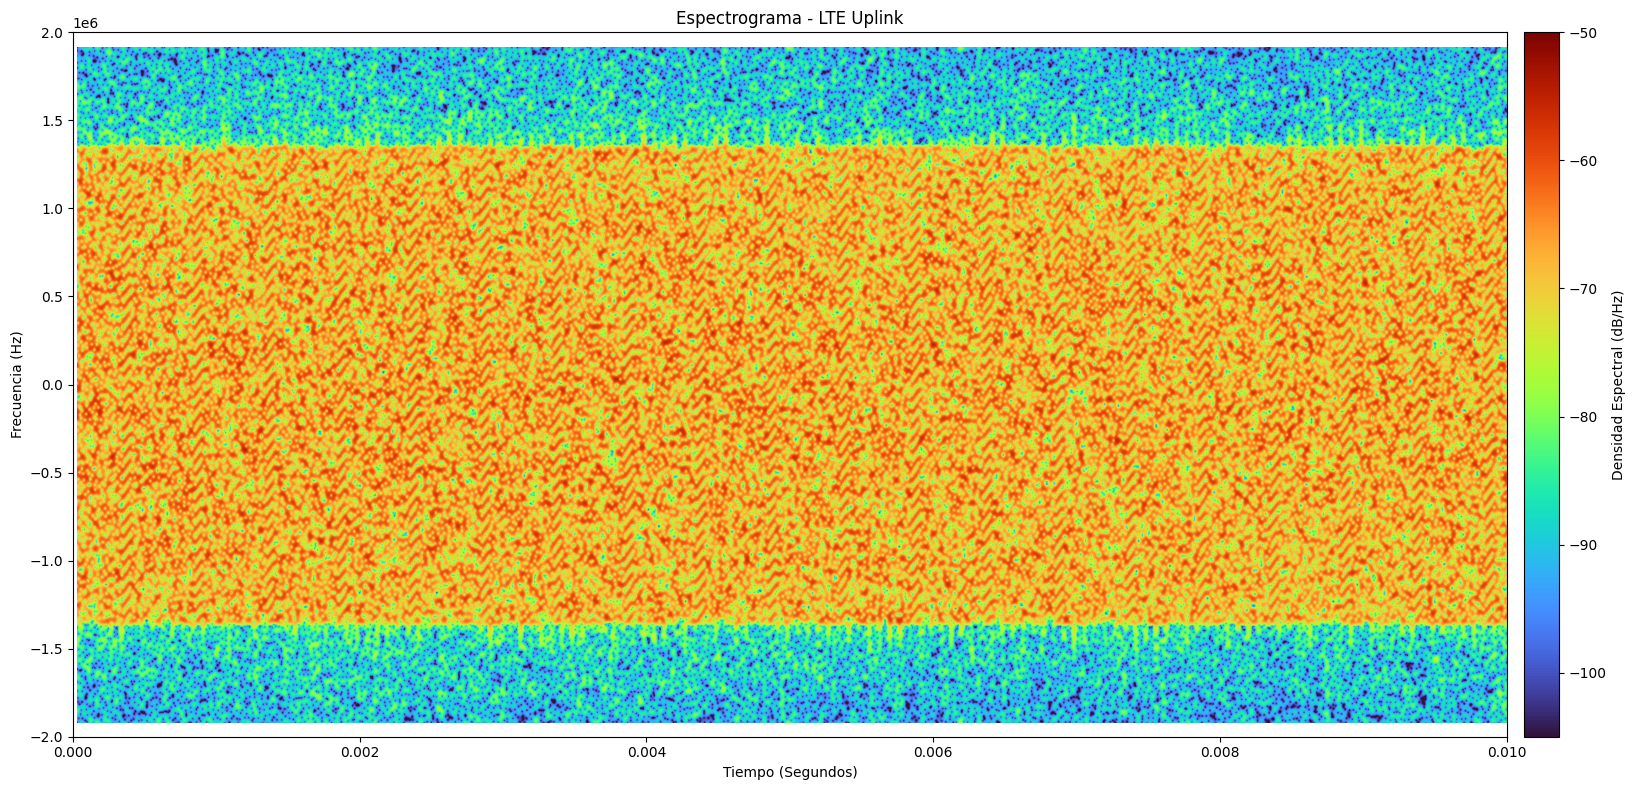

In [347]:
import matplotlib.pyplot as plt                                                                                                                                  
import numpy as np                                                                                                                                               
                                                                                                                                                                    
# Esto permite que el gráfico se dibuje directamente dentro del notebook                                                                                         
%matplotlib inline                                                                                                                                               
                                                                                                                                                                    
# Aumentamos el tamaño de la figura para verlo gigante                                                                                     
plt.figure(figsize=(18, 8))                                                                                                                
                                                                                                                                            
powerSpectrum, frequenciesFound, time_axis, imageAxis = plt.specgram(                                                                      
    recv_buffer,                                                                                                                           
    NFFT=256,            # Ventana de 66 microsegundos (cabe justo en 1 símbolo LTE)
    pad_to=2048,         # ZERO-PADDING: Suaviza la frecuencia multiplicando la resolución x8
    Fs=sample_rate,
    cmap='turbo',        # 'turbo' da muchísimo contraste visual para RF
    scale='dB',
    noverlap=240,        # Paso ultracorto (avanza de a 16 muestras) para máxima fluidez de tiempo
    vmin=-105,           # Recortamos el ruido estático oscuro
    vmax=-50             # Saturamos un poquito los picos para que resalten
)

plt.title("Espectrograma - LTE Uplink")
plt.xlabel("Tiempo (Segundos)")
plt.ylabel("Frecuencia (Hz)")

 # === ZOOM ===                                                                                                                   
# 1. Zoom en Frecuencia: Vemos solo de -2 MHz a +2 MHz (donde está el PSS/SSS)                                                             
plt.ylim([-2e6, 2e6])                                                                                                                      
                                                                                                                                            
# 2. Zoom en Tiempo                                                            
plt.xlim([0, 0.01])                                                                                                                        
# ====================== 

# Agregar la barra lateral para leer los niveles de potencia
cbar = plt.colorbar(pad=0.01)
cbar.set_label("Densidad Espectral (dB/Hz)")

# Ajustar los bordes para que quede prolijo
plt.tight_layout()
plt.show()

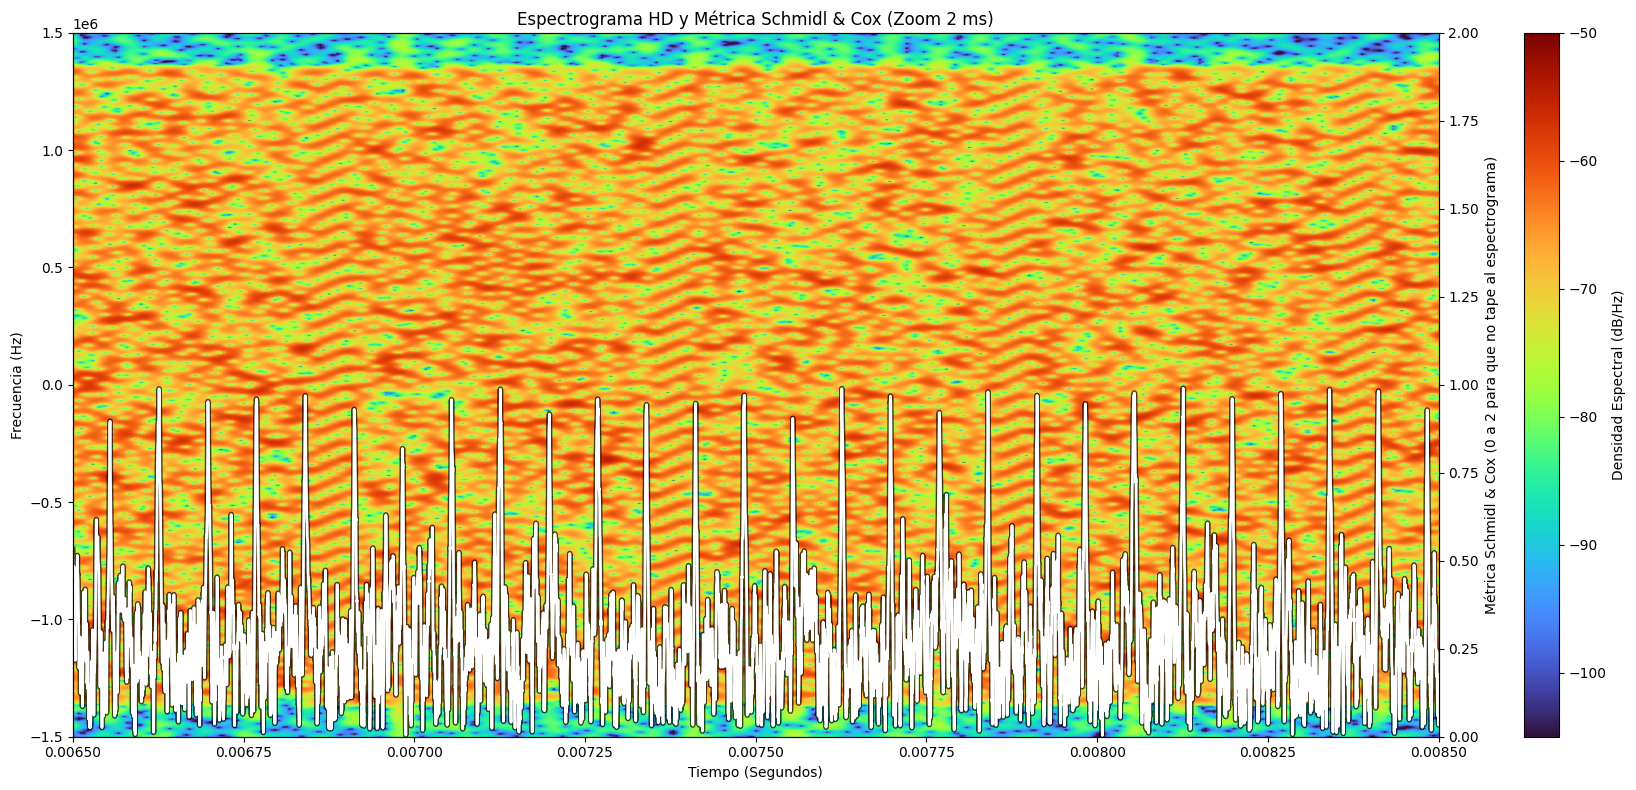

In [348]:
import numpy as np                                                                                                                         
import matplotlib.pyplot as plt     

# --- 0. Limpieza de señal (SDR) ---                                                                                                       
# Eliminar el DC offset del hardware (Fuga del Oscilador Local)                                                                            
recv_buffer = recv_buffer - np.mean(recv_buffer)
                                                                                                                                            
# --- 1. Cálculos de Schmidl & Cox ---                                                                                                     
Tu = 256                                                                                                                                   
Tcp = 20  # Usamos el CP largo: matchea perfecto con sym 0/7, y pierde solo
          # 2 muestras de correlación en los demás (despreciable).                                                                                                                                   
                                                                                                                                            
# Compensar 7.5 kHz para el Uplink                                                                                                         
tiempo_offset = np.arange(len(recv_buffer)) / sample_rate                                                                                  
recv_buffer_shifted = recv_buffer * np.exp(1j * 2 * np.pi * 7500 * tiempo_offset)                                                          
                                                                                                                                            
x = recv_buffer_shifted[:-Tu]                                                                                                              
x_adelantado = recv_buffer_shifted[Tu:]                                                                                                    
producto_cruzado = x * np.conj(x_adelantado)                                                                                               
                                                                                                                                            
# Integración                                                                                                                              
ventana = np.ones(Tcp)                                                                                                                     
correlacion = np.convolve(producto_cruzado, ventana, mode='valid')                                                                         
                                                                                                                                            
# Normalización robusta (Promedio de energías)                                                                                             
energia_x = np.convolve(np.abs(x)**2, ventana, mode='valid')                                                                               
energia_adelantada = np.convolve(np.abs(x_adelantado)**2, ventana, mode='valid')                                                           
energia_promedio = 0.5 * (energia_x + energia_adelantada)                                                                                  
                                                                                                                                            
metrica_schmidl = np.abs(correlacion) / (energia_promedio + 1e-10)                                                                         
                                                                                                                                            
# Squelch (Compuerta de Energía): Forzar a 0 donde no hay señal real                                                                       
umbral_energia = np.max(energia_promedio) * 0.05                                                                                           
metrica_schmidl[energia_promedio < umbral_energia] = 0                                                                                     
                                                                                                                                            
tiempo_sc = np.arange(len(metrica_schmidl)) / sample_rate                                                                                  
                                                                                                                                            
# --- 2. Graficar todo superpuesto ---                                                                                                     
fig, ax1 = plt.subplots(figsize=(18, 8))                                                                                                    
                                                                                                                                            
# El espectrograma va en el eje principal (ax1)                                                                                            
powerSpectrum, frequenciesFound, time_axis, imageAxis = ax1.specgram(                                                                      
    recv_buffer,                                                                                                                           
    NFFT=256,                                                                                                                              
    pad_to=2048,                                                                                                                           
    Fs=sample_rate,                                                                                                                        
    cmap='turbo',                                                                                                                          
    scale='dB',                                                                                                                            
    noverlap=240,
    vmin=-105,
    vmax=-50
)

ax1.set_title("Espectrograma HD y Métrica Schmidl & Cox (Zoom 2 ms)")
ax1.set_xlabel("Tiempo (Segundos)")
ax1.set_ylabel("Frecuencia (Hz)")

# Ajustamos los límites tal como los tenías (adaptando la frec. a 3 MHz)
ax1.set_ylim([-1.5e6, 1.5e6]) 
ax1.set_xlim([0.0065, 0.0085]) # Tus 2 milisegundos

# Barra de color del espectrograma
cbar = fig.colorbar(imageAxis, ax=ax1, pad=0.05)
cbar.set_label("Densidad Espectral (dB/Hz)")

# El gráfico de la métrica va en un eje secundario (ax2) que comparte la X
ax2 = ax1.twinx()

# Truco visual: Línea negra de sombra y cyan arriba para que se vea siempre
ax2.plot(tiempo_sc, metrica_schmidl, color='black', linewidth=4, alpha=0.7)
ax2.plot(tiempo_sc, metrica_schmidl, color='white', linewidth=2)

ax2.set_ylabel("Métrica Schmidl & Cox (0 a 2 para que no tape al espectrograma)")
ax2.set_ylim([0, 2]) # Dejamos un margen arriba de los picos

fig.tight_layout()
plt.show()

In [349]:
# 1. Encontrar el inicio EXACTO de la ráfaga
picos_fuertes = np.where(metrica_schmidl > 0.8)[0]
if len(picos_fuertes) == 0:
    raise ValueError("No se encontró señal LTE. Verificar que el CMW500 esté transmitiendo.")
primer_cluster = picos_fuertes[picos_fuertes < picos_fuertes[0] + 50]
indice_pico = primer_cluster[np.argmax(metrica_schmidl[primer_cluster])]
print(f"Pico de correlación en la muestra: {indice_pico}")

# 2. Parámetros
Tu = 256
cp_largo = 20
cp_corto = 18

# --- ESTIMACIÓN DE CFO ---
# NOTA: Como el S&C se calculó sobre recv_buffer_shifted (con +7500 Hz),
# el CFO estimado incluye esos 7500 Hz. Al aplicarlo sobre recv_buffer original,
# corrige simultáneamente el CFO del hardware Y el offset de 7.5 kHz del uplink LTE.
cfo_estimado = -np.angle(correlacion[indice_pico]) * sample_rate / (2 * np.pi * Tu)
print(f"CFO estimado: {cfo_estimado:.1f} Hz")

t_vec = np.arange(len(recv_buffer)) / sample_rate
recv_buffer_cfo = recv_buffer * np.exp(-1j * 2 * np.pi * cfo_estimado * t_vec)

# --- BÚSQUEDA DE TIMING ÓPTIMO ---
best_evm = float('inf')
best_correction = 0

for correction in range(-15, 16):
    a0_test = indice_pico + cp_largo + correction
    sym_time = recv_buffer_cfo[a0_test : a0_test + Tu]
    sym_time = sym_time * np.exp(-1j * np.pi * np.arange(Tu) / Tu)
    sym_fft = np.fft.fftshift(np.fft.fft(sym_time))
    sc = sym_fft[38:218]
    data = np.fft.ifft(sc)
    phase = np.angle(np.mean(data**4)) / 4
    data_corr = data * np.exp(-1j * phase)
    evm = 1.0 - np.abs(np.mean((data_corr / np.sqrt(np.mean(np.abs(data_corr)**2)))**4))
    if evm < best_evm:
        best_evm = evm
        best_correction = correction

print(f"Corrección de timing óptima: {best_correction} muestras (EVM métrica: {best_evm:.4f})")

# --- DEMODULACIÓN CON PARÁMETROS ÓPTIMOS ---
# NOTA: Esta fórmula de extracción asume que S&C aterrizó en el símbolo 0.
# Si aterrizó en otro símbolo, habrá ±2 muestras de error en algunos símbolos.
# La Celda 11 corrige esto con el patrón de CP rotado (CP_alineado).
a0 = indice_pico + cp_largo + best_correction
symbols_data = []
symbols_dmrs = []  # NUEVO: Guardamos los DMRS acá

for i in range(14):
    delta = (cp_largo - cp_corto) * (i // 7)
    start = a0 + i * (Tu + cp_corto) + delta
    symbol_time = recv_buffer_cfo[start : start + Tu]
    
    symbol_time = symbol_time * np.exp(-1j * np.pi * np.arange(Tu) / Tu)
    simbolo_fft = np.fft.fftshift(np.fft.fft(symbol_time))
    subcarriers = simbolo_fft[38:218]
    
    if i % 7 != 3:  # Datos PUSCH (requieren IFFT para deshacer SC-FDMA)
        symbols_data.append(np.fft.ifft(subcarriers))
    else:            # DMRS (es OFDM puro, no lleva IFFT de precodificación)
        symbols_dmrs.append(subcarriers)  # DMRS en frecuencia, sin normalización

print(f"Demodulados {len(symbols_data)} símbolos PUSCH y {len(symbols_dmrs)} símbolos DMRS")


Pico de correlación en la muestra: 208
CFO estimado: -1512.7 Hz
Corrección de timing óptima: -10 muestras (EVM métrica: 0.0150)
Demodulados 12 símbolos PUSCH y 2 símbolos DMRS


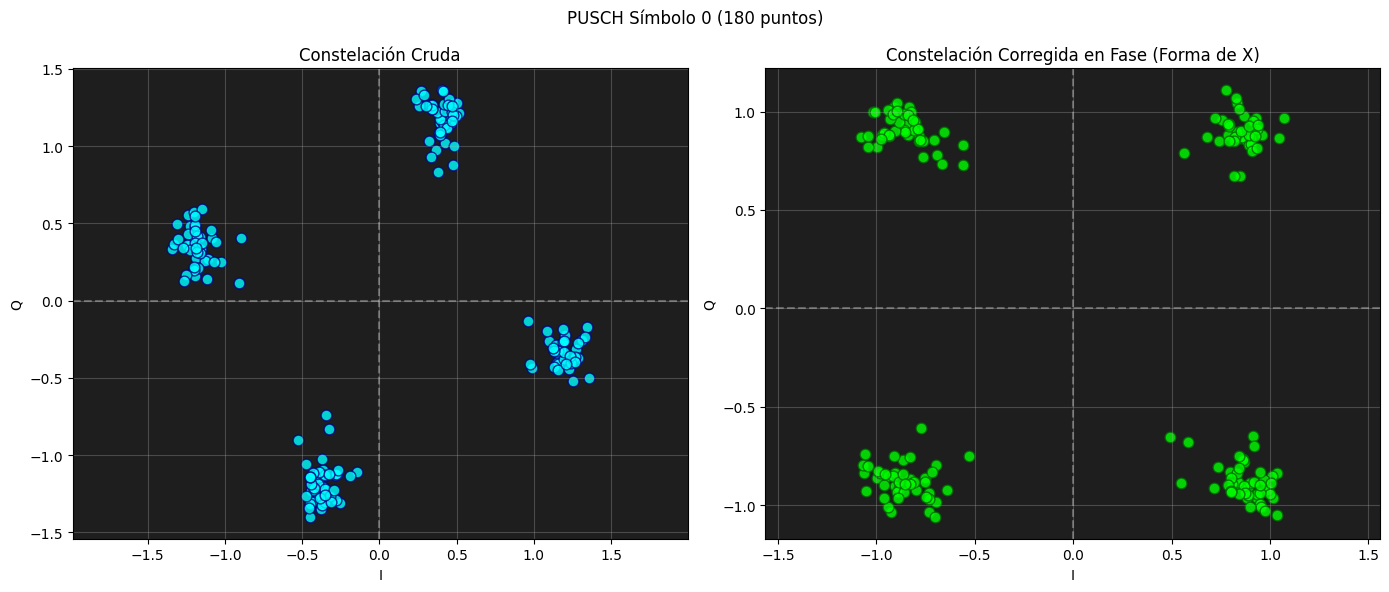

In [350]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Tomar el primer símbolo de datos PUSCH
datos_scfdma = symbols_data[0]

# --- Panel 1: Cruda ---
ax = axes[0]
ax.scatter(np.real(datos_scfdma), np.imag(datos_scfdma), 
        color='cyan', alpha=0.8, edgecolors='navy', s=60)
ax.axhline(0, color='white', linestyle='--', alpha=0.3)
ax.axvline(0, color='white', linestyle='--', alpha=0.3)
ax.set_title("Constelación Cruda")
ax.set_xlabel("I")
ax.set_ylabel("Q")
ax.axis('equal')
ax.grid(True, alpha=0.3)
ax.set_facecolor('#1e1e1e')

# --- Panel 2: Con corrección de fase ---
# Viterbi-Viterbi para QPSK: mean(d^4) elimina la modulación y deja solo el error de fase.
# Dividimos por 4 para deshacer la potencia, y restamos π/4 para colocar los puntos
# ideales en (±1 ±1j) en forma de 'X'.
# NOTA: (angle - π)/4 ≡ angle/4 - π/4, algebraicamente idéntico a las Celdas 9/11.
fase_estimada = (np.angle(np.mean(datos_scfdma**4)) - np.pi) / 4
datos_corregidos = datos_scfdma * np.exp(-1j * fase_estimada)

ax = axes[1]
ax.scatter(np.real(datos_corregidos), np.imag(datos_corregidos), 
        color='lime', alpha=0.8, edgecolors='darkgreen', s=60)
ax.axhline(0, color='white', linestyle='--', alpha=0.3)
ax.axvline(0, color='white', linestyle='--', alpha=0.3)
ax.set_title("Constelación Corregida en Fase (Forma de X)")
ax.set_xlabel("I")
ax.set_ylabel("Q")
ax.axis('equal')
ax.grid(True, alpha=0.3)
ax.set_facecolor('#1e1e1e')

plt.suptitle(f"PUSCH Símbolo 0 ({len(datos_scfdma)} puntos)")
plt.tight_layout()
plt.show()


In [351]:
# === CAPTURA DE DOWNLINK PARA OBTENER CELL ID ===
import sys
import time
sys.path.append('/home/alanastasio/repos/auto/demodulador/demodulador')
from dsp.demoduladores import lte_downlink

# 1. Deducir frecuencia DL desde la frecuencia UL configurada en Celda 0
f_ul = center_freq
f_dl = None

# Mapeo básico de separación duplex LTE (FDD)
if 1710e6 <= f_ul <= 1785e6:
    if f_ul <= 1755e6: # Band 4 tiene 400 MHz de gap, Band 3 tiene 95 MHz
        f_dl = f_ul + 400e6  # Asumimos AWS Band 4 por defecto en esta zona
    else:
        f_dl = f_ul + 95e6
elif 1850e6 <= f_ul <= 1910e6:
    f_dl = f_ul + 80e6 # Band 2
elif 2500e6 <= f_ul <= 2570e6:
    f_dl = f_ul + 120e6 # Band 7
elif 703e6 <= f_ul <= 748e6:
    f_dl = f_ul + 55e6 # Band 28
else:
    f_dl = f_ul + 400e6
    print("Banda UL no reconocida, asumiendo offset de AWS (+400 MHz)")

print(f"Frecuencia Uplink Original: {f_ul/1e6} MHz")
print(f"Saltando a Frecuencia Downlink: {f_dl/1e6} MHz...")

# 2. Captura corta del Downlink
tiempo_dl = 0.05  # 50 ms es suficiente para capturar varios PSS/SSS
samps_dl = int(sample_rate * tiempo_dl)

# Liberar la instancia de usrp si existiera para evitar choques (aunque en la celda 0 ya cerró el stream)
usrp_dl = uhd.usrp.MultiUSRP("type=b200")
usrp_dl.set_master_clock_rate(61.44e6)
usrp_dl.set_rx_rate(sample_rate, 0)
usrp_dl.set_rx_bandwidth(sample_rate, 0)
usrp_dl.set_rx_freq(uhd.types.TuneRequest(f_dl), 0)
usrp_dl.set_rx_gain(ganancia, 0)

# Darle tiempo al PLL para estabilizarse en la nueva frecuencia
time.sleep(0.1)

st_args = uhd.usrp.StreamArgs("fc32", "sc16")
st_args.channels = [0]
streamer_dl = usrp_dl.get_rx_stream(st_args)

stream_cmd = uhd.types.StreamCMD(uhd.types.StreamMode.start_cont)
stream_cmd.stream_now = True
streamer_dl.issue_stream_cmd(stream_cmd)

recv_dl = np.zeros(samps_dl, dtype=np.complex64)
metadata = uhd.types.RXMetadata()

samps_recibidas_dl = 0
buffer_chunk = np.zeros(streamer_dl.get_max_num_samps(), dtype=np.complex64)

while samps_recibidas_dl < samps_dl:
    s = streamer_dl.recv(buffer_chunk, metadata)
    if s > 0:
        s_copy = min(s, samps_dl - samps_recibidas_dl)
        recv_dl[samps_recibidas_dl : samps_recibidas_dl + s_copy] = buffer_chunk[:s_copy]
        samps_recibidas_dl += s_copy

streamer_dl.issue_stream_cmd(uhd.types.StreamCMD(uhd.types.StreamMode.stop_cont))
print(f"Captura Downlink de {samps_dl} muestras completada.")

# 3. Extraer el Cell ID usando tu demodulador existente
print("Procesando señal DL para extraer Cell ID...")
demod_dl = lte_downlink.DemoduladorLTEDownlink()
# FFT 256 para 3 MHz
demod_dl.configurar(sample_rate, 256)
demod_dl._procesar_fondo(recv_dl)

cell_id = None
if 'cell_id' in demod_dl.ultimo_lte_metrics:
    cell_id = demod_dl.ultimo_lte_metrics['cell_id']
    print(f"✅ ¡CELL ID DETECTADO EXACTAMENTE IGUAL QUE EN EL DEMODULADOR!: {cell_id}")
else:
    cell_id = 5  # Fallback seguro
    print(f"⚠️ No se pudo leer el Cell ID, forzando a fallback manual: {cell_id}")


Frecuencia Uplink Original: 1732.5 MHz
Saltando a Frecuencia Downlink: 2132.5 MHz...
Captura Downlink de 192000 muestras completada.
Procesando señal DL para extraer Cell ID...


[INFO] [B200] Asking for clock rate 61.440000 MHz... 
[INFO] [B200] OK


✅ ¡CELL ID DETECTADO EXACTAMENTE IGUAL QUE EN EL DEMODULADOR!: 5


DMRS detectados en símbolos: 4 (CV=0.0753) y 11 (CV=0.0680)

DMRS 1 (símbolo 4): u=5, v=0, α=1
  → Residuo Linealidad: 0.0718 | Pendiente STO: 0.2303 rad/sc

DMRS 2 (símbolo 11): u=5, v=0, α=8
  → Residuo Linealidad: 0.0716 | Pendiente STO: 0.2303 rad/sc


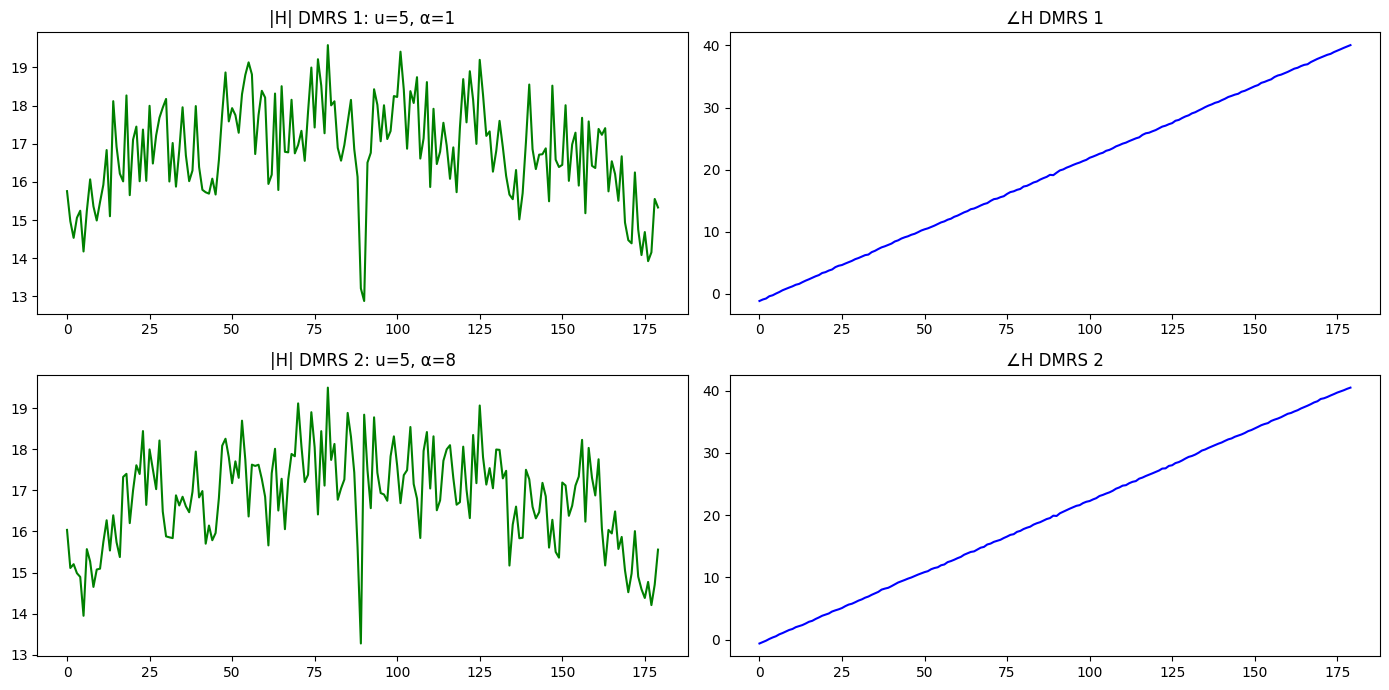

In [352]:
# === 8. BÚSQUEDA ZC DEFINITIVA (CRITERIO FÍSICO: Rectitud y Pendiente Mínima) ===
import numpy as np
import matplotlib.pyplot as plt

# --- Paso 1: Extraer los 14 símbolos en frecuencia ---
all_subcarriers = []
for i in range(14):
    delta = (cp_largo - cp_corto) * (i // 7)
    start = a0 + i * (Tu + cp_corto) + delta
    sym = recv_buffer_cfo[start : start + Tu]
    sym = sym * np.exp(-1j * np.pi * np.arange(Tu) / Tu)
    fft_out = np.fft.fftshift(np.fft.fft(sym))
    sc = fft_out[38:218]
    all_subcarriers.append(sc)

# --- Paso 2: Encontrar los 2 DMRS por amplitud constante ---
cvs = []
for sc in all_subcarriers:
    amp = np.abs(sc)
    cvs.append(np.std(amp) / np.mean(amp))

indices_ord = np.argsort(cvs)
dmrs_real_0 = min(indices_ord[0], indices_ord[1])
dmrs_real_1 = max(indices_ord[0], indices_ord[1])

print(f"DMRS detectados en símbolos: {dmrs_real_0} (CV={cvs[dmrs_real_0]:.4f}) y {dmrs_real_1} (CV={cvs[dmrs_real_1]:.4f})")

def generar_dmrs_lte(u, v, alpha_idx, N_rb=15):
    M_sc = N_rb * 12
    N_zc = 179 # largest prime < 180
    q_bar = N_zc * (u + 1) / 31.0
    q = np.floor(q_bar + 0.5) + v * ((-1)**int(np.floor(2 * q_bar)))
    m = np.arange(N_zc)
    x_q = np.exp(-1j * np.pi * q * m * (m + 1) / N_zc)
    n = np.arange(M_sc)
    r_base = x_q[n % N_zc]
    alpha = 2 * np.pi * alpha_idx / 12.0
    return r_base * np.exp(1j * alpha * n)

# --- Paso 3: Búsqueda Física ---
x = np.arange(180)

for dmrs_idx, dmrs_sym in enumerate([dmrs_real_0, dmrs_real_1]):
    sc_dmrs = all_subcarriers[dmrs_sym]
    
    # 1. Buscar u, v que minimicen el residuo de linealidad de fase
    mejor_residual = float('inf')
    mejor_u, mejor_v = -1, -1
    
    # Rango de búsqueda: 30 grupos para el DMRS 1, heredar para DMRS 2
    u_range = range(30) if dmrs_idx == 0 else [u_final]
    
    for u in u_range:
        for v in [0, 1]:
            seq_base = generar_dmrs_lte(u, v, 0, N_rb=15)
            H_base = sc_dmrs / seq_base
            phase = np.unwrap(np.angle(H_base))
            coeffs = np.polyfit(x, phase, 1)
            residual = np.std(phase - np.polyval(coeffs, x))
            
            if residual < mejor_residual:
                mejor_residual = residual
                mejor_u, mejor_v = u, v
    
    if dmrs_idx == 0:
        u_final, v_final = mejor_u, mejor_v
        
    # 2. Buscar el alpha que dé la pendiente de fase más cercana a 0 (menor delay)
    mejor_slope_abs = float('inf')
    mejor_alpha = -1
    mejor_H = None
    mejor_slope = 0
    
    for alpha_idx in range(12):
        seq = generar_dmrs_lte(u_final, v_final, alpha_idx, N_rb=15)
        H = sc_dmrs / seq
        phase = np.unwrap(np.angle(H))
        slope = np.polyfit(x, phase, 1)[0]
        
        if abs(slope) < mejor_slope_abs:
            mejor_slope_abs = abs(slope)
            mejor_alpha = alpha_idx
            mejor_H = H
            mejor_slope = slope

    if dmrs_idx == 0:
        alpha_1 = mejor_alpha
        mejor_H_1 = mejor_H
    else:
        alpha_2 = mejor_alpha
        mejor_H_2 = mejor_H
        
    print(f"\nDMRS {dmrs_idx+1} (símbolo {dmrs_sym}): u={u_final}, v={v_final}, α={mejor_alpha}")
    print(f"  → Residuo Linealidad: {mejor_residual:.4f} | Pendiente STO: {mejor_slope:.4f} rad/sc")

# --- Paso 4: Plotear H ---
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
axes[0,0].plot(np.abs(mejor_H_1), color='green'); axes[0,0].set_title(f"|H| DMRS 1: u={u_final}, α={alpha_1}")
axes[0,1].plot(np.unwrap(np.angle(mejor_H_1)), color='blue'); axes[0,1].set_title(f"∠H DMRS 1")
axes[1,0].plot(np.abs(mejor_H_2), color='green'); axes[1,0].set_title(f"|H| DMRS 2: u={u_final}, α={alpha_2}")
axes[1,1].plot(np.unwrap(np.angle(mejor_H_2)), color='blue'); axes[1,1].set_title(f"∠H DMRS 2")
plt.tight_layout(); plt.show()


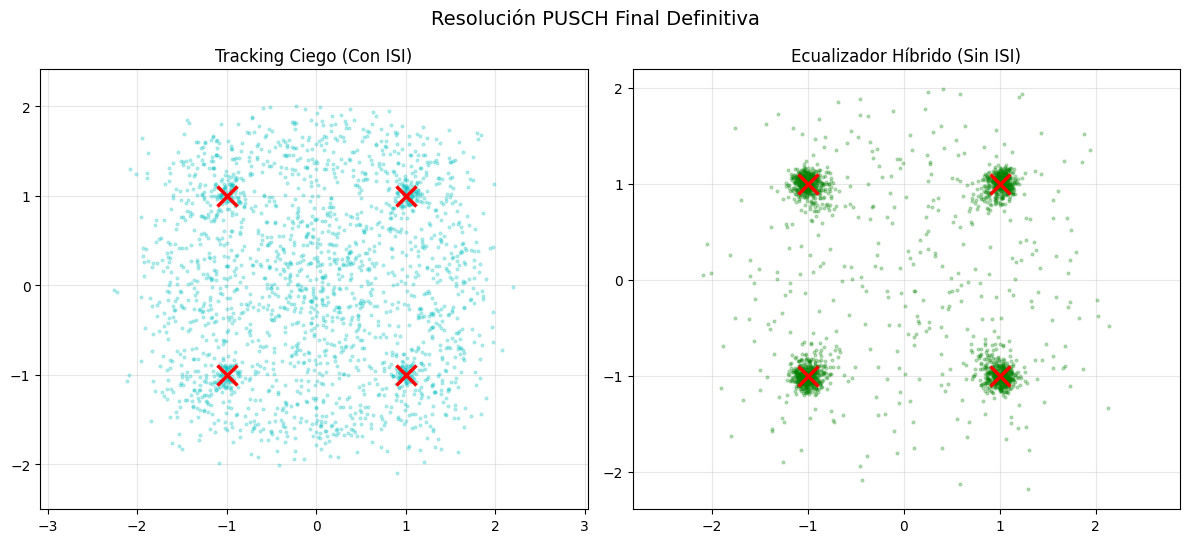


📊 EVM Tracking Ciego : 51.91%
📊 EVM Ecualizado     : 24.53%
📊 Diferencia         : 27.38 pp


In [353]:
# === 9. ECUALIZACIÓN FINAL HÍBRIDA ===
import matplotlib.pyplot as plt

p1, p2 = dmrs_real_0, dmrs_real_1
x = np.arange(180)

# Suavizado de H (Magnitud polinomial + Pendiente lineal pura)
p_mag_1 = np.polyfit(x, np.abs(mejor_H_1), 3)
p_mag_2 = np.polyfit(x, np.abs(mejor_H_2), 3)

slope_1 = np.polyfit(x, np.unwrap(np.angle(mejor_H_1)), 1)[0]
slope_2 = np.polyfit(x, np.unwrap(np.angle(mejor_H_2)), 1)[0]

# Pre-calcular las curvas suavizadas (no dependen del símbolo i)
mag_1_smooth = np.polyval(p_mag_1, x)
mag_2_smooth = np.polyval(p_mag_2, x)

def H_hibrida(i):
    t = np.clip((i - p1) / (p2 - p1), -0.5, 1.5)
    mag = mag_1_smooth * (1 - t) + mag_2_smooth * t
    slope = slope_1 * (1 - t) + slope_2 * t
    # SOLO aplicamos la pendiente (delay). Ignoramos fase absoluta para evitar aliasing del CFO.
    phase = slope * (x - 90)  # Centrado en SC central para minimizar offset de fase DC
    return mag * np.exp(1j * phase)

ideal_pts = np.array([1+1j, 1-1j, -1+1j, -1-1j])
rotaciones = [np.exp(1j * k * np.pi / 2) for k in range(4)]

all_eq = []
all_raw = []

for i in range(14):
    if i == p1 or i == p2: continue
    sc = all_subcarriers[i]
    
    # --- Tracking Ciego (Solo IFFT + VV) ---
    d_raw = np.fft.ifft(sc)
    d_raw_n = d_raw * (np.sqrt(2) / np.sqrt(np.mean(np.abs(d_raw)**2)))
    ph_raw = np.angle(np.mean(d_raw_n**4)) / 4
    d_raw_c = d_raw_n * np.exp(-1j * (ph_raw - np.pi/4))
    
    b_err = float('inf'); b_raw = d_raw_c
    for rot in rotaciones:
        c = d_raw_c * rot
        e = np.mean(np.min(np.abs(c[:, None] - ideal_pts[None, :]), axis=1)**2)
        if e < b_err: b_err = e; b_raw = c
    all_raw.extend(b_raw)
    
    # --- Ecualizador Híbrido (H_hibrida corrige USRP + STO, VV corrige CFO) ---
    d_eq = np.fft.ifft(sc / H_hibrida(i))
    d_eq_n = d_eq * (np.sqrt(2) / np.sqrt(np.mean(np.abs(d_eq)**2)))
    ph_eq = np.angle(np.mean(d_eq_n**4)) / 4
    d_eq_c = d_eq_n * np.exp(-1j * (ph_eq - np.pi/4))
    
    b_err = float('inf'); b_eq = d_eq_c
    for rot in rotaciones:
        c = d_eq_c * rot
        e = np.mean(np.min(np.abs(c[:, None] - ideal_pts[None, :]), axis=1)**2)
        if e < b_err: b_err = e; b_eq = c
    all_eq.extend(b_eq)

all_raw, all_eq = np.array(all_raw), np.array(all_eq)

# --- Ploteo ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
axes[0].plot(all_raw.real, all_raw.imag, 'c.', alpha=0.25, markersize=4)
axes[0].plot(ideal_pts.real, ideal_pts.imag, 'rx', markersize=14, markeredgewidth=2.5)
axes[0].set_title(f'Tracking Ciego (Con ISI)'); axes[0].axis('equal'); axes[0].grid(True, alpha=0.3)

axes[1].plot(all_eq.real, all_eq.imag, 'g.', alpha=0.25, markersize=4)
axes[1].plot(ideal_pts.real, ideal_pts.imag, 'rx', markersize=14, markeredgewidth=2.5)
axes[1].set_title(f'Ecualizador Híbrido (Sin ISI)'); axes[1].axis('equal'); axes[1].grid(True, alpha=0.3)

plt.suptitle("Resolución PUSCH Final Definitiva", fontsize=14)
plt.tight_layout(); plt.show()

# --- EVM ---
ref_norm = ideal_pts / np.sqrt(2)
pts_raw = all_raw / np.sqrt(np.mean(np.abs(all_raw)**2))
e_raw = np.sqrt(np.mean(np.min(np.abs(pts_raw[:, None] - ref_norm[None, :]), axis=1)**2)) * 100
pts_eq = all_eq / np.sqrt(np.mean(np.abs(all_eq)**2))
e_eq = np.sqrt(np.mean(np.min(np.abs(pts_eq[:, None] - ref_norm[None, :]), axis=1)**2)) * 100

print(f"\n📊 EVM Tracking Ciego : {e_raw:.2f}%")
print(f"📊 EVM Ecualizado     : {e_eq:.2f}%")
print(f"📊 Diferencia         : {e_raw - e_eq:.2f} pp")


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


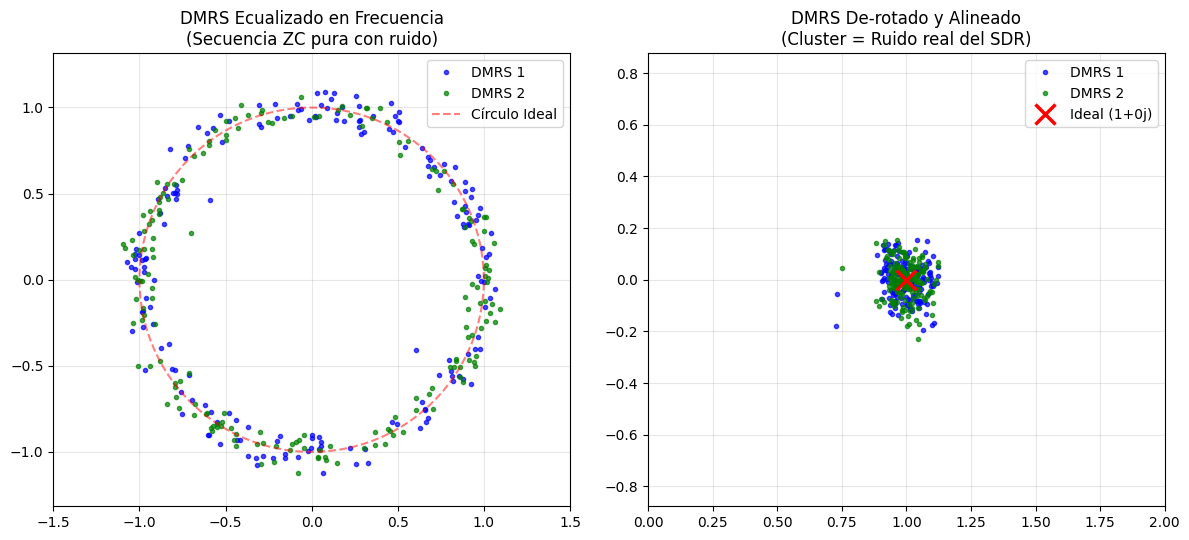

📊 EVM DMRS 1 : 9.48%
📊 EVM DMRS 2 : 8.87%


In [354]:
# === 10. VERIFICACIÓN DEL DMRS ECUALIZADO ===
import matplotlib.pyplot as plt
import numpy as np

# 1. Secuencias matemáticas teóricas
seq1 = generar_dmrs_lte(u_final, v_final, alpha_1, N_rb=15)
seq2 = generar_dmrs_lte(u_final, v_final, alpha_2, N_rb=15)

# 2. Ecualizamos los DMRS recibidos con nuestro Ecualizador Híbrido
sc1_eq = all_subcarriers[dmrs_real_0] / H_hibrida(dmrs_real_0)
sc2_eq = all_subcarriers[dmrs_real_1] / H_hibrida(dmrs_real_1)

# 3. De-rotamos (multiplicamos por la conjugada teórica)
derot1 = sc1_eq * np.conj(seq1)
derot2 = sc2_eq * np.conj(seq2)

# 4. Alineamos la fase media 
# (Recordá que H_hibrida ignora la fase absoluta para evitar aliasing, 
# así que la corregimos aquí tal como lo hace el Viterbi-Viterbi en los datos)
derot1_aligned = derot1 * np.exp(-1j * np.angle(np.mean(derot1)))
derot2_aligned = derot2 * np.exp(-1j * np.angle(np.mean(derot2)))

# --- Ploteo ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

axes[0].plot(sc1_eq.real, sc1_eq.imag, 'b.', label='DMRS 1', alpha=0.7)
axes[0].plot(sc2_eq.real, sc2_eq.imag, 'g.', label='DMRS 2', alpha=0.7)
theta = np.linspace(0, 2*np.pi, 100)
axes[0].plot(np.cos(theta), np.sin(theta), 'r--', alpha=0.5, label='Círculo Ideal')
axes[0].set_title('DMRS Ecualizado en Frecuencia\n(Secuencia ZC pura con ruido)')
axes[0].axis('equal'); axes[0].grid(True, alpha=0.3); axes[0].legend()
axes[0].set_xlim([-1.5, 1.5]); axes[0].set_ylim([-1.5, 1.5])

axes[1].plot(derot1_aligned.real, derot1_aligned.imag, 'b.', label='DMRS 1', alpha=0.7)
axes[1].plot(derot2_aligned.real, derot2_aligned.imag, 'g.', label='DMRS 2', alpha=0.7)
axes[1].plot(1, 0, 'rx', markersize=14, markeredgewidth=2.5, label='Ideal (1+0j)')
axes[1].set_title('DMRS De-rotado y Alineado\n(Cluster = Ruido real del SDR)')
axes[1].axis('equal'); axes[1].grid(True, alpha=0.3); axes[1].legend()
axes[1].set_xlim([0, 2]); axes[1].set_ylim([-1, 1])

plt.tight_layout()
plt.show()

# --- EVM ---
evm_dmrs1 = np.sqrt(np.mean(np.abs(derot1_aligned - 1)**2)) * 100
evm_dmrs2 = np.sqrt(np.mean(np.abs(derot2_aligned - 1)**2)) * 100

print(f"📊 EVM DMRS 1 : {evm_dmrs1:.2f}%")
print(f"📊 EVM DMRS 2 : {evm_dmrs2:.2f}%")


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


--- Sincronización Absoluta ---
a0 original cayó en Símbolo Real : 13
Corrección Micro (Fase DMRS)     : -9 muestras
Puntero a0 Perfecto              : 218 -> 209

Pendiente residual final (DMRS 1): 0.0585 rad/sc
⚠️ Pendiente residual alta (0.0585). Considerar iterar la corrección.


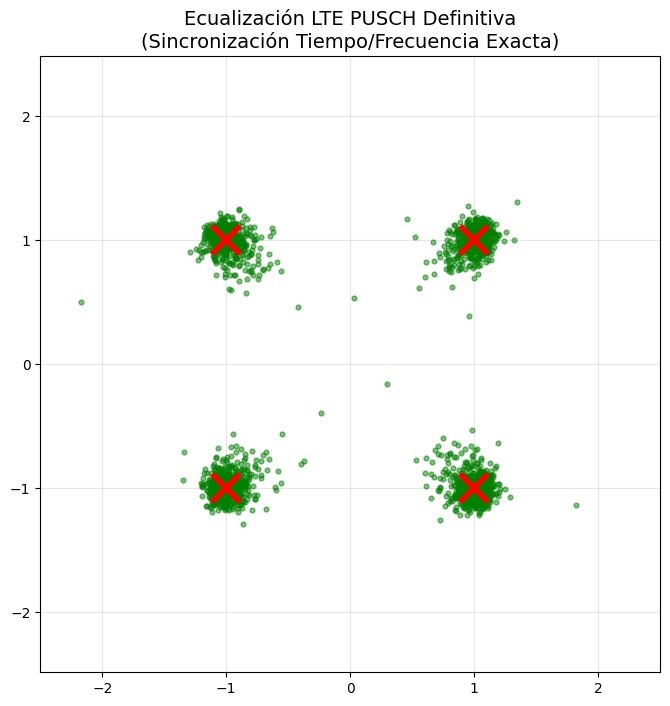


EVM por símbolo:
 Símbolo Extraído  0 (Real 13): 12.11%
 Símbolo Extraído  1 (Real  0): 9.06%
 Símbolo Extraído  2 (Real  1): 12.33%
 Símbolo Extraído  3 (Real  2): 12.52%
 Símbolo Extraído  5 (Real  4): 11.84%
 Símbolo Extraído  6 (Real  5): 11.10%
 Símbolo Extraído  7 (Real  6): 9.50%
 Símbolo Extraído  8 (Real  7): 10.25%
 Símbolo Extraído  9 (Real  8): 11.86%
 Símbolo Extraído 10 (Real  9): 10.78%
 Símbolo Extraído 12 (Real 11): 11.37%
 Símbolo Extraído 13 (Real 12): 11.34%

📊 EVM Final Absoluto (12 Símbolos) : 11.22%


In [355]:
# === 11. BUCLE CERRADO: SINCRONIZACIÓN ABSOLUTA PERFECTA ===
import matplotlib.pyplot as plt
import numpy as np

# 1. Deducción del Símbolo Real
simbolo_arranque = (3 - dmrs_real_0) % 14
print(f"--- Sincronización Absoluta ---")
print(f"a0 original cayó en Símbolo Real : {simbolo_arranque}")

# 2. Rotar el patrón de CP 
CP_pattern = [20, 18, 18, 18, 18, 18, 18, 20, 18, 18, 18, 18, 18, 18]
CP_alineado = CP_pattern[simbolo_arranque:] + CP_pattern[:simbolo_arranque]

# 3. Micro-sincronización (Corrección de fase fina STO)
error_muestras = int(np.round(slope_1 * 256 / (2 * np.pi)))
a0_perfecto = a0 - error_muestras

if a0_perfecto < 0:
    print(f"⚠️ a0_perfecto = {a0_perfecto} (negativo). Señal muy cerca del inicio del buffer.")
    print(f"   Considerar aumentar el tiempo de captura.")
    a0_perfecto = 0

print(f"Corrección Micro (Fase DMRS)     : {-error_muestras} muestras")
print(f"Puntero a0 Perfecto              : {a0} -> {a0_perfecto}\n")

# 4. Extraer los 14 símbolos (Corregido el off-by-one del salto de CP)
all_subcarriers_p = []
for i in range(14):
    # El salto hasta los datos del símbolo i depende de los CPs de los símbolos 1 a i.
    delta_cp = sum(CP_alineado[1 : i+1]) 
    start = a0_perfecto + i * 256 + delta_cp
    
    sym = recv_buffer_cfo[start : start + 256]
    sym = sym * np.exp(-1j * np.pi * np.arange(256) / 256)
    fft_out = np.fft.fftshift(np.fft.fft(sym))
    all_subcarriers_p.append(fft_out[38:218])

# 5. Recalcular Canal
p1, p2 = dmrs_real_0, dmrs_real_1
seq1 = generar_dmrs_lte(u_final, v_final, alpha_1, N_rb=15)
seq2 = generar_dmrs_lte(u_final, v_final, alpha_2, N_rb=15)

H1_p = all_subcarriers_p[p1] / seq1
H2_p = all_subcarriers_p[p2] / seq2

x = np.arange(180)
p_mag_1_p = np.polyfit(x, np.abs(H1_p), 3)
p_mag_2_p = np.polyfit(x, np.abs(H2_p), 3)

slope_1_p = np.polyfit(x, np.unwrap(np.angle(H1_p)), 1)[0]
slope_2_p = np.polyfit(x, np.unwrap(np.angle(H2_p)), 1)[0]
print(f"Pendiente residual final (DMRS 1): {slope_1_p:.4f} rad/sc")
if abs(slope_1_p) > 0.05:
    print(f"⚠️ Pendiente residual alta ({slope_1_p:.4f}). Considerar iterar la corrección.")

# Pre-calcular las curvas suavizadas (no dependen del símbolo i)
mag_1_smooth_p = np.polyval(p_mag_1_p, x)
mag_2_smooth_p = np.polyval(p_mag_2_p, x)

def H_hibrida_p(i):
    t = np.clip((i - p1) / (p2 - p1), -0.5, 1.5)
    mag = mag_1_smooth_p * (1 - t) + mag_2_smooth_p * t
    slope = slope_1_p * (1 - t) + slope_2_p * t
    phase = slope * (x - 90)
    return mag * np.exp(1j * phase)

# 6. Ecualizar
ideal_pts = np.array([1+1j, 1-1j, -1+1j, -1-1j])
rotaciones = [np.exp(1j * k * np.pi / 2) for k in range(4)]

all_eq_p = []
evm_per_sym = []
for i in range(len(all_subcarriers_p)):
    if i == p1 or i == p2: continue
    sc = all_subcarriers_p[i]
    
    d_eq = np.fft.ifft(sc / H_hibrida_p(i))
    d_eq_n = d_eq * (np.sqrt(2) / np.sqrt(np.mean(np.abs(d_eq)**2)))
    ph_eq = np.angle(np.mean(d_eq_n**4)) / 4
    d_eq_c = d_eq_n * np.exp(-1j * (ph_eq - np.pi/4))
    
    b_err = float('inf'); b_eq = d_eq_c
    for rot in rotaciones:
        c = d_eq_c * rot
        e = np.mean(np.min(np.abs(c[:, None] - ideal_pts[None, :]), axis=1)**2)
        if e < b_err: b_err = e; b_eq = c
    all_eq_p.extend(b_eq)
    evm_per_sym.append((i, np.sqrt(b_err/2)*100))

all_eq_p = np.array(all_eq_p)

# 7. Ploteo y EVM
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(all_eq_p.real, all_eq_p.imag, 'g.', alpha=0.5, markersize=7)
ax.plot(ideal_pts.real, ideal_pts.imag, 'rx', markersize=20, markeredgewidth=4)
ax.set_title(f"Ecualización LTE PUSCH Definitiva\n(Sincronización Tiempo/Frecuencia Exacta)", fontsize=14)
ax.axis('equal'); ax.grid(True, alpha=0.3)
ax.set_xlim([-2.5, 2.5]); ax.set_ylim([-2.5, 2.5])
plt.show()

print("\nEVM por símbolo:")
for i, evm in evm_per_sym:
    idx_real = (i + simbolo_arranque) % 14
    print(f" Símbolo Extraído {i:2d} (Real {idx_real:2d}): {evm:.2f}%")

ref_norm = ideal_pts / np.sqrt(2)
pts_p = all_eq_p / np.sqrt(np.mean(np.abs(all_eq_p)**2))
e_p = np.sqrt(np.mean(np.min(np.abs(pts_p[:, None] - ref_norm[None, :]), axis=1)**2)) * 100
print(f"\n📊 EVM Final Absoluto (12 Símbolos) : {e_p:.2f}%")


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


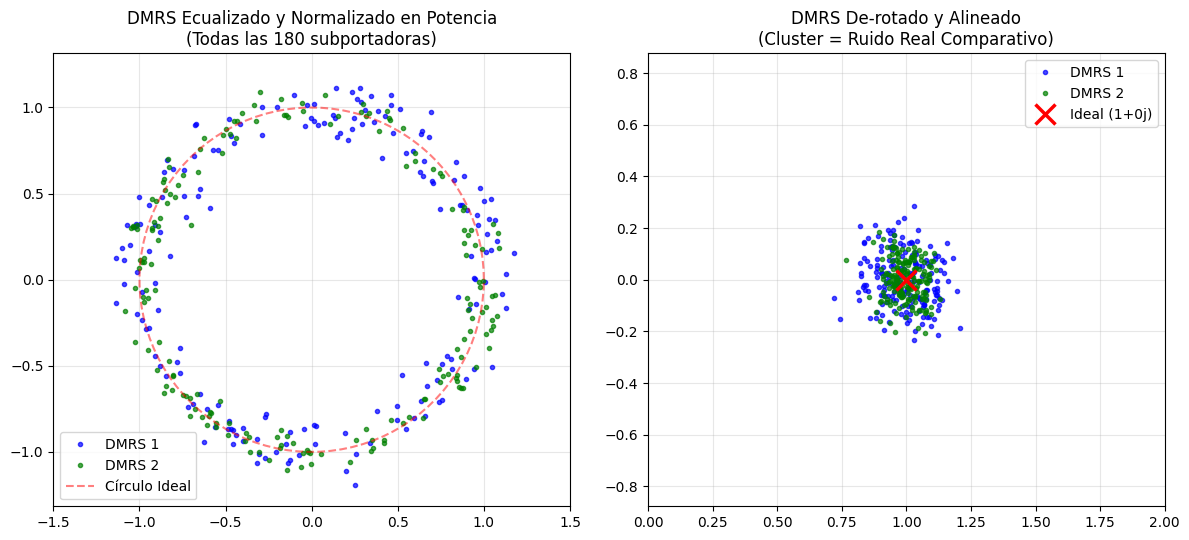

📊 EVM DMRS 1 (Normalizado) : 14.09%
📊 EVM DMRS 2 (Normalizado) : 9.93%


In [356]:
# === 12. VERIFICACIÓN DEL DMRS CON ESCALA NORMALIZADA ===
import matplotlib.pyplot as plt
import numpy as np

# 1. Ecualizamos los DMRS recibidos con el Ecualizador Híbrido
sc1_eq_p = all_subcarriers_p[p1] / H_hibrida_p(p1)
sc2_eq_p = all_subcarriers_p[p2] / H_hibrida_p(p2)

# 2. Normalizamos la potencia RMS (Igual que se hace con el QPSK)
# Esto compensa el sesgo de magnitud del ruido y pone la nube en el centro correcto
sc1_eq_norm = sc1_eq_p / np.sqrt(np.mean(np.abs(sc1_eq_p)**2))
sc2_eq_norm = sc2_eq_p / np.sqrt(np.mean(np.abs(sc2_eq_p)**2))

# 3. De-rotamos
derot1_p = sc1_eq_norm * np.conj(seq1)
derot2_p = sc2_eq_norm * np.conj(seq2)

# 4. Alineamos la fase media
derot1_aligned = derot1_p * np.exp(-1j * np.angle(np.mean(derot1_p)))
derot2_aligned = derot2_p * np.exp(-1j * np.angle(np.mean(derot2_p)))

# --- Ploteo ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

axes[0].plot(sc1_eq_norm.real, sc1_eq_norm.imag, 'b.', label='DMRS 1', alpha=0.7)
axes[0].plot(sc2_eq_norm.real, sc2_eq_norm.imag, 'g.', label='DMRS 2', alpha=0.7)
theta = np.linspace(0, 2*np.pi, 100)
axes[0].plot(np.cos(theta), np.sin(theta), 'r--', alpha=0.5, label='Círculo Ideal')
axes[0].set_title('DMRS Ecualizado y Normalizado en Potencia\n(Todas las 180 subportadoras)')
axes[0].axis('equal'); axes[0].grid(True, alpha=0.3); axes[0].legend()
axes[0].set_xlim([-1.5, 1.5]); axes[0].set_ylim([-1.5, 1.5])

axes[1].plot(derot1_aligned.real, derot1_aligned.imag, 'b.', label='DMRS 1', alpha=0.7)
axes[1].plot(derot2_aligned.real, derot2_aligned.imag, 'g.', label='DMRS 2', alpha=0.7)
axes[1].plot(1, 0, 'rx', markersize=14, markeredgewidth=2.5, label='Ideal (1+0j)')
axes[1].set_title('DMRS De-rotado y Alineado\n(Cluster = Ruido Real Comparativo)')
axes[1].axis('equal'); axes[1].grid(True, alpha=0.3); axes[1].legend()
axes[1].set_xlim([0, 2]); axes[1].set_ylim([-1, 1])

plt.tight_layout()
plt.show()

# --- EVM ---
evm_dmrs1 = np.sqrt(np.mean(np.abs(derot1_aligned - 1)**2)) * 100
evm_dmrs2 = np.sqrt(np.mean(np.abs(derot2_aligned - 1)**2)) * 100

print(f"📊 EVM DMRS 1 (Normalizado) : {evm_dmrs1:.2f}%")
print(f"📊 EVM DMRS 2 (Normalizado) : {evm_dmrs2:.2f}%")
